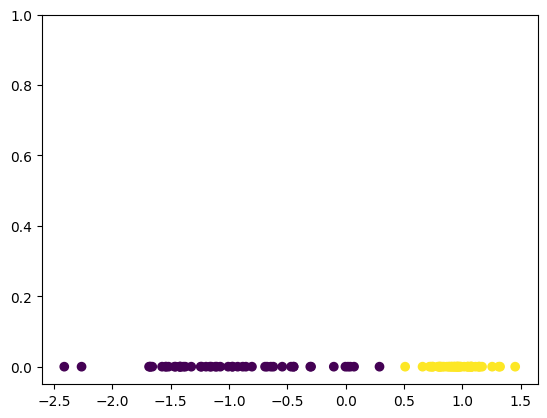

In [62]:
import sys
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(n_classes=2, n_features=1,
               n_redundant=0, n_repeated=0, n_informative=1,
               n_clusters_per_class=1, class_sep=1.0, random_state=1)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X, np.zeros_like(y), c=y)
plt.ylim(-0.05, 1)
plt.savefig('set.png')

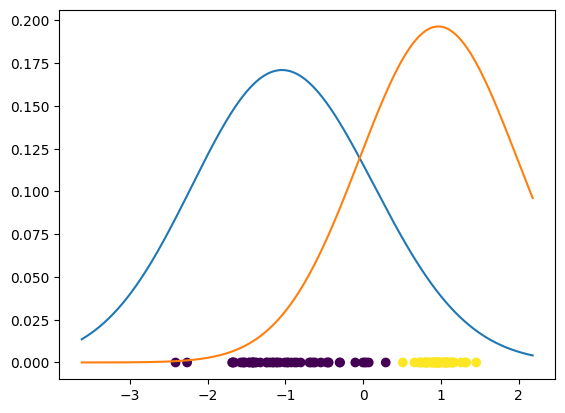

In [63]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity

class BayesKDE(BaseEstimator, ClassifierMixin):
  def __init__(self, bandwidth=1.0):
    self.bandwidth = bandwidth

  def fit(self, X, y):
    self.classes_ = np.unique(y)

    self.kdes_ = {}
    self.priors_ = {}

    for target in self.classes_:
      kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
      kde.fit(X[y == target])
      self.kdes_[target] = kde

      self.priors_[target] = np.sum(y == target) / len(y)

    return self
  
  def score_samples(self, X):
    logprobs = np.zeros((len(X), len(self.classes_)))

    for i, target in enumerate(self.classes_):
      logprobs[:, i] = self.kdes_[target].score_samples(X) + np.log(self.priors_[target])

    return logprobs
  
  def predict(self, X):
    logprobs = self.score_samples(X)
    return np.argmax(logprobs, axis=1)

bayeskde = BayesKDE()
bayeskde.fit(X, y)
plt.figure()
plt.scatter(X, np.zeros_like(y), c=y)
x = np.linspace(np.min(X) * 1.5, np.max(X) * 1.5, 1000).reshape(-1, 1)
plt.plot(x, np.exp(bayeskde.score_samples(x)[:, 0]))
plt.plot(x, np.exp(bayeskde.score_samples(x)[:, 1]))
plt.savefig('pdfs.png')
plt.show()

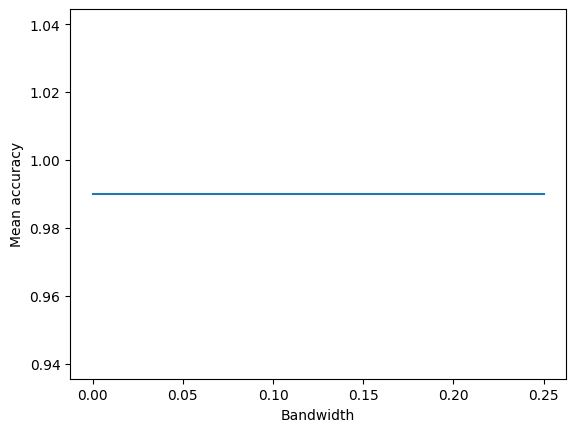

In [64]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=0)
bws = np.linspace(sys.float_info.epsilon, 0.25, 100)

mean_scores = []

for bw in bws:
  bayeskde = BayesKDE(bandwidth=bw)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))

plt.figure()
plt.plot(bws, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bw_search.png')
plt.show()

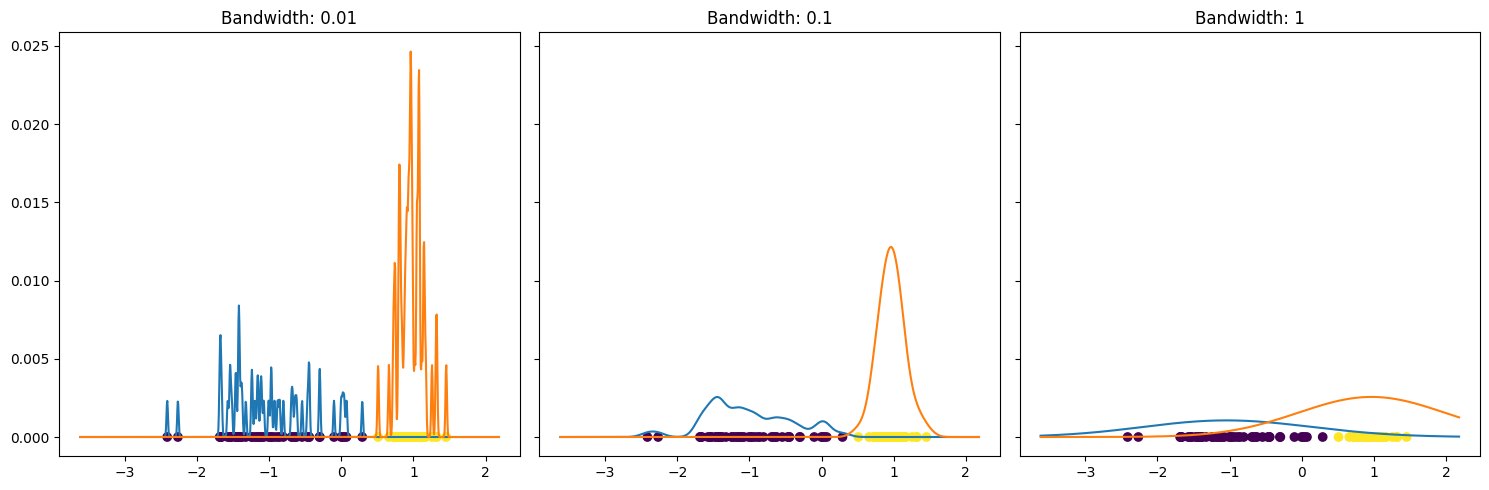

In [65]:
test_bws = [0.01, 0.1, 1]

x = np.linspace(np.min(X) * 1.5, np.max(X) * 1.5, 1000).reshape(-1, 1)

fig, axs = plt.subplots(1, len(test_bws), figsize=(15, 5), sharey=True)

for i, bw in enumerate(test_bws):
  bayeskde = BayesKDE(bandwidth=bw)
  bayeskde.fit(X, y)
  axs[i].scatter(X, np.zeros_like(y), c=y)
  p0 = np.exp(bayeskde.score_samples(x)[:, 0])
  p1 = np.exp(bayeskde.score_samples(x)[:, 1])
  p0 = p0 / np.sum(p0 + p1)
  p1 = p1 / np.sum(p0 + p1)
  axs[i].plot(x, p0)
  axs[i].plot(x, p1)
  axs[i].set_title(f'Bandwidth: {bw}')

plt.tight_layout()
plt.savefig('pdf_x_bw.png')
plt.show()

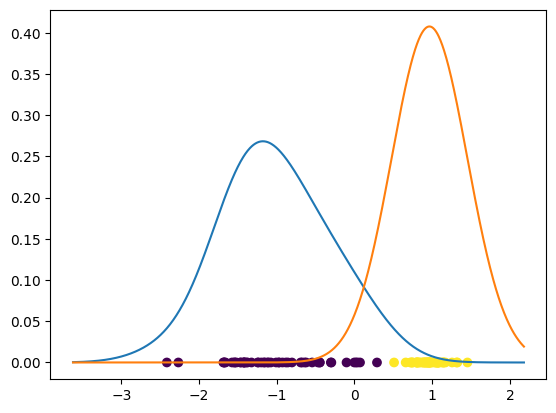

Accuracy: 0.990 +/- 0.030


In [66]:
silverman_h = 1.06 * np.std(X) * len(X) ** (-1/5)

bayeskde = BayesKDE(bandwidth=silverman_h)
bayeskde.fit(X, y)
x = np.linspace(np.min(X) * 1.5, np.max(X) * 1.5, 1000).reshape(-1, 1)

pdf0 = np.exp(bayeskde.score_samples(x)[:, 0])
pdf1 = np.exp(bayeskde.score_samples(x)[:, 1])

plt.figure()
plt.scatter(X, np.zeros_like(y), c=y)
plt.plot(x, pdf0)
plt.plot(x, pdf1)

plt.show()

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=0)
acc = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
print(f'Accuracy: {np.mean(acc):.3f} +/- {np.std(acc):.3f}')

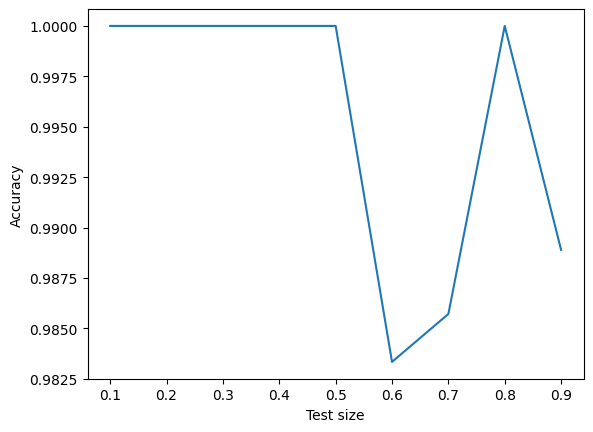

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tsizes = np.linspace(0.1, 0.9, 9)

scores = []

for ts in tsizes:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=0)
  bayeskde = BayesKDE(bandwidth=0.1)
  bayeskde.fit(X_train, y_train)
  y_pred = bayeskde.predict(X_test)
  scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(tsizes, scores)
plt.xlabel('Test size')
plt.ylabel('Accuracy')
plt.savefig('tsize_search.png')
plt.show()

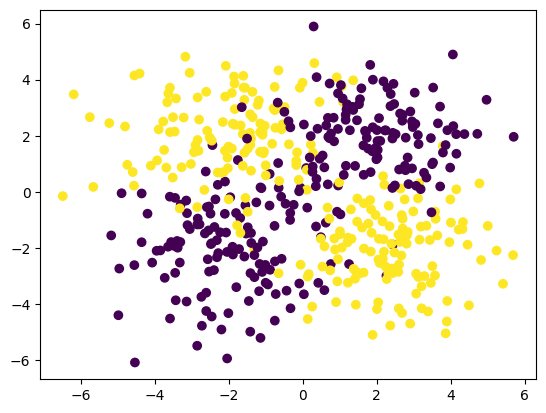

In [68]:
from sklearn.datasets import make_blobs

def make_xor(n_samples=1000, noise=0.0):

  samples_per_class = n_samples // 4

  X = np.vstack([
    np.random.normal(loc=(-2, -2), size=(samples_per_class, 2)),
    np.random.normal(loc=(-2, 2), size=(samples_per_class, 2)),
    np.random.normal(loc=(2, -2), size=(samples_per_class, 2)),
    np.random.normal(loc=(2, 2), size=(samples_per_class, 2))
  ])

  y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)

  X += np.random.normal(0, noise, X.shape)

  return X, y

X, y = make_xor(n_samples=500, noise=1.00)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.savefig('xor_set.png')
plt.show()

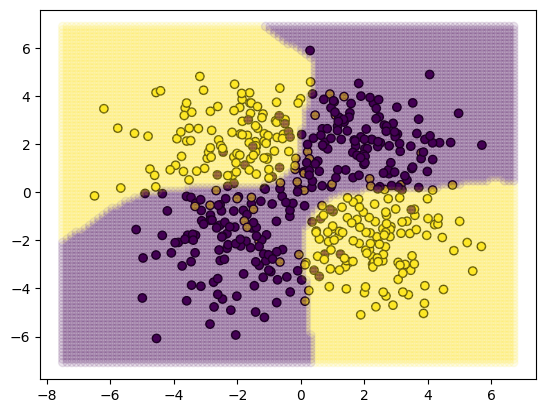

In [69]:
def make_grid(X: np.ndarray, target_points: int = 10000) -> np.ndarray:
  """
  Create an adaptive grid of points for decision boundaries, balancing resolution and computation time.
  
  Parameters:
    X (np.ndarray): Input data points.
    target_points (int): Approximate number of grid points (default: 10000).
  
  Returns:
    np.ndarray: Grid of points shaped (n_samples, 2).
  """
  # Calculate data range with padding
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

  # Handle edge cases where range is zero
  x_range = x_max - x_min
  y_range = y_max - y_min
  if x_range <= 0:
    x_range = 1e-5
    x_max = x_min + x_range
  if y_range <= 0:
    y_range = 1e-5
    y_max = y_min + y_range

  # Calculate aspect ratio and determine grid dimensions
  aspect_ratio = x_range / y_range
  nx = int(np.round(np.sqrt(target_points * aspect_ratio)))
  ny = int(np.round(np.sqrt(target_points / aspect_ratio)))
  nx, ny = max(nx, 1), max(ny, 1)  # Ensure at least 1 point per axis

  # Generate evenly spaced grid
  xx = np.linspace(x_min, x_max, nx)
  yy = np.linspace(y_min, y_max, ny)
  xx_mesh, yy_mesh = np.meshgrid(xx, yy)
  
  return np.c_[xx_mesh.ravel(), yy_mesh.ravel()]


G = make_grid(X)

bayeskde = BayesKDE()

bayeskde.fit(X, y)

Z = bayeskde.predict(G)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.scatter(G[:, 0], G[:, 1], c=Z, alpha=0.1)
plt.savefig('xor_decision.png')
plt.show()

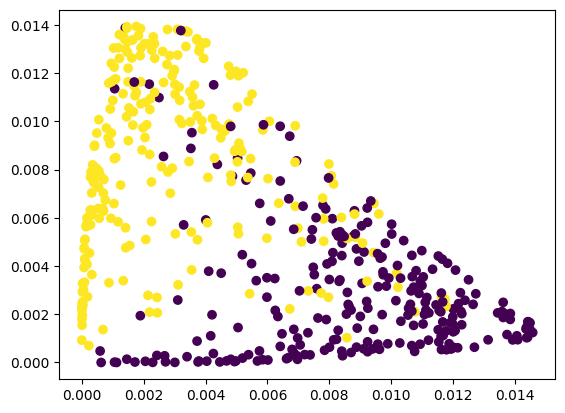

In [70]:
logprobs = bayeskde.score_samples(X)

[Q0, Q1] = logprobs.T

Q0, Q1 = np.exp(Q0), np.exp(Q1)

plt.figure()
plt.scatter(Q0, Q1, c=y)
plt.savefig('xor_likelihood.png')
plt.show()

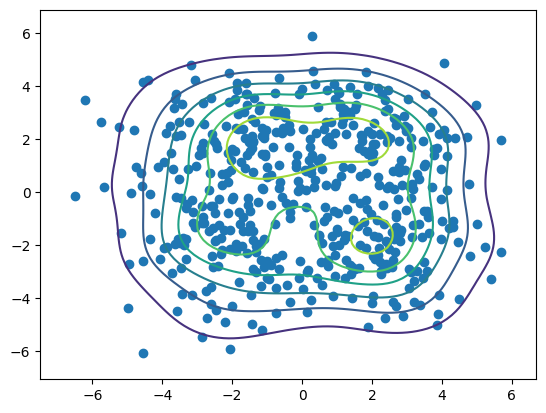

In [71]:
kde = KernelDensity()

kde.fit(X)

logprobs = kde.score_samples(G)

Z = np.exp(logprobs)

plt.figure()

# Determine grid dimensions using unique coordinates
unique_x = np.unique(G[:, 0])
unique_y = np.unique(G[:, 1])
ny, nx = len(unique_y), len(unique_x)

# Reshape Z and grid points correctly
Z = Z.reshape(ny, nx)
XX = G[:, 0].reshape(ny, nx)
YY = G[:, 1].reshape(ny, nx)

plt.contour(XX, YY, Z)
plt.scatter(X[:, 0], X[:, 1])
plt.savefig('xor_kde.png')
plt.show()

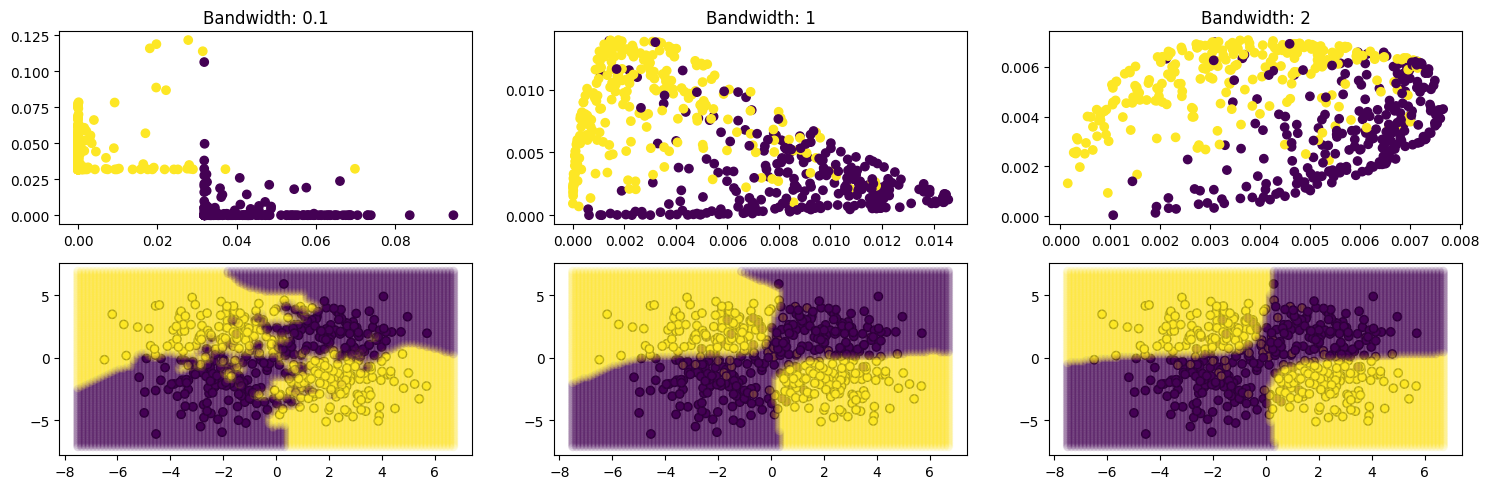

In [72]:
hs = [0.1, 1, 2]

fig, axs = plt.subplots(2, len(hs), figsize=(15, 5))

for i, h in enumerate(hs):
  bayeskde = BayesKDE(bandwidth=h)
  bayeskde.fit(X, y)

  logprobs = bayeskde.score_samples(X)
  [Q0, Q1] = logprobs.T
  Q0, Q1 = np.exp(Q0), np.exp(Q1)

  axs[0, i].scatter(Q0, Q1, c=y)
  axs[0, i].set_title(f'Bandwidth: {h}')

  G = make_grid(X)

  Z = bayeskde.predict(G)

  axs[1, i].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
  axs[1, i].scatter(G[:, 0], G[:, 1], c=Z, alpha=0.1)

plt.tight_layout()
plt.savefig('xor_bw.png')
plt.show()
  

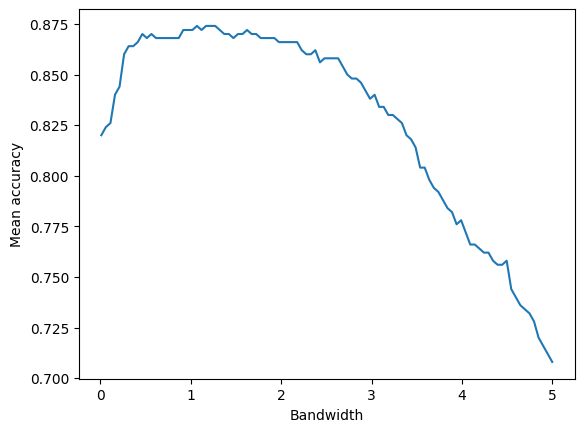

In [73]:
hs = np.linspace(0.01, 5, 100)

mean_scores = []

for h in hs:
  bayeskde = BayesKDE(bandwidth=h)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))
plt.figure()
plt.plot(hs, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('xor_bw_search_acc.png')
plt.show()

Accuracy: 0.754 +/- 0.059


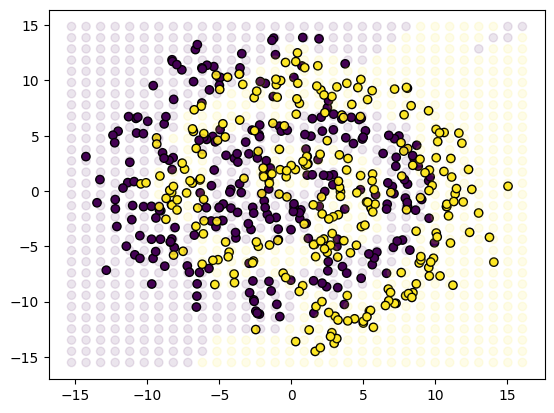

In [74]:
def make_spirals(n_samples: int=100, noise: float=0.0, turns: int=1) -> tuple[np.ndarray, np.ndarray]:
  """
  Generate a spirals dataset.

  Parameters
  ----------
  n_samples : int, optional
    The number of samples to generate, by default 100
  noise : float, optional
    The standard deviation of the Gaussian noise added to the data, by default 0.0

  Returns
  -------
  tuple[np.ndarray, np.ndarray]
    A tuple containing the generated data points and their corresponding labels.
  """

  samples_per_class = n_samples // 2

  n = np.sqrt(np.random.rand(n_samples)) * 2 * turns * np.pi
  x = n * np.sin(n) + np.random.randn(n_samples) * noise
  y = n * np.cos(n) + np.random.randn(n_samples) * noise
  
  X = np.array(list(zip(x, y)))
  y = np.array([0] * samples_per_class + [1] * samples_per_class)
  
  # Rotate one class 180 degrees
  X[samples_per_class:] = -X[samples_per_class:]
  
  return X, y

X, y = make_spirals(n_samples=500, noise=1.5, turns=2)

bayeskde = BayesKDE()
bayeskde.fit(X, y)
acc = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
print(f'Accuracy: {np.mean(acc):.3f} +/- {np.std(acc):.3f}')

G = make_grid(X, target_points=1000)

Z = bayeskde.predict(G)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.scatter(G[:, 0], G[:, 1], c=Z, alpha=0.1)
plt.show()
